## Scenariusz symulacji

W tym scenariuszu przedstawiona jest detekcja monostatyczna zgodna z zamysłem 6G ISAC. W tej sytuacji założeniem jest wykrycie Dopplera spowodowanego przez ruch człowieka czy też samochodu.

In [1]:
%matplotlib inline

# Importowanie najwazniejszych bibliotek
import numpy as np
import matplotlib.pyplot as plt

# Importowanie najwazniejszych komponentow Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, PathSolver, RadioMapSolver, subcarrier_frequencies, RadioMaterial

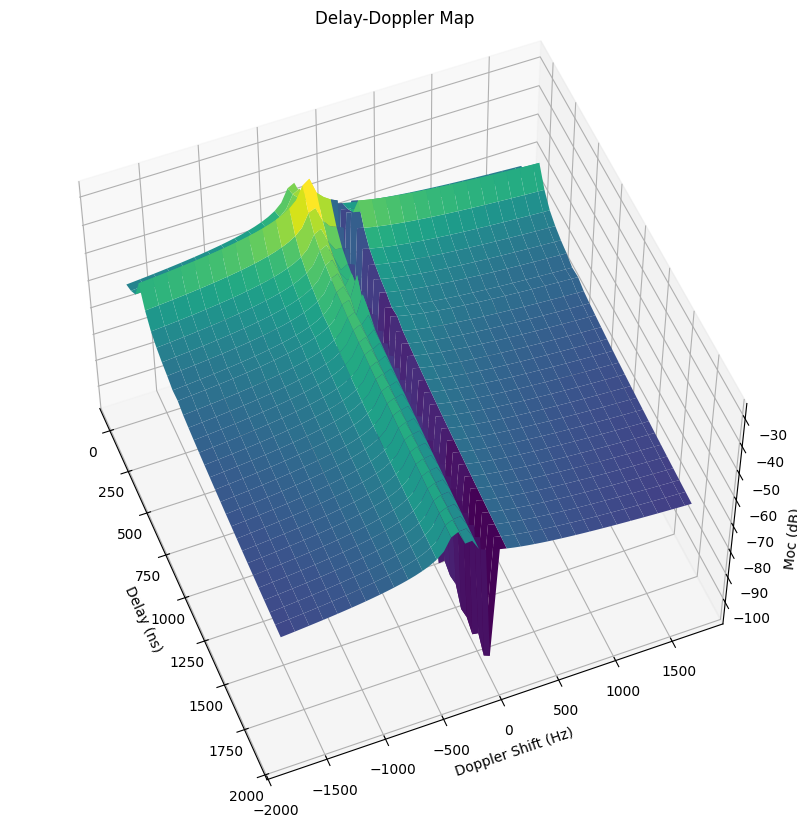

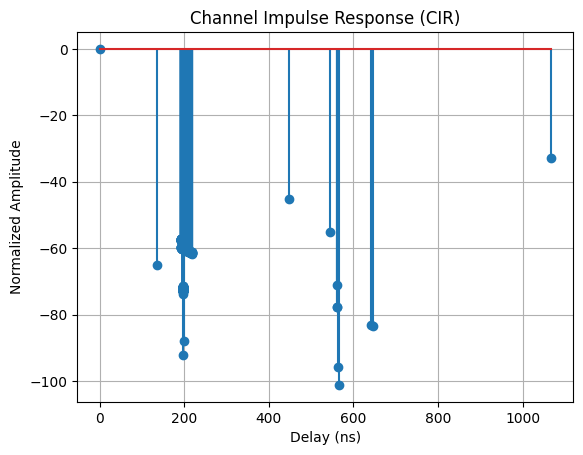

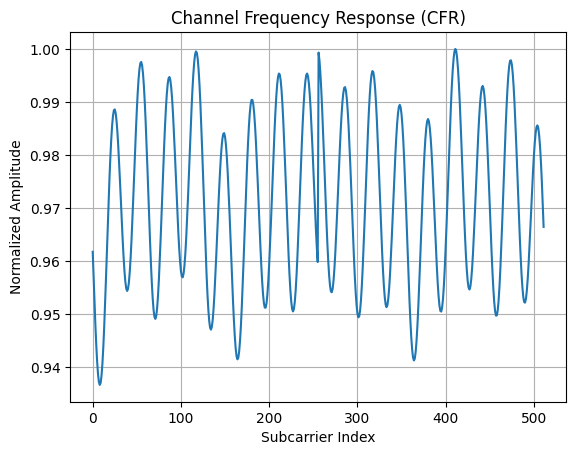

In [2]:
scene = load_scene("./OpenStreetMap/kampus_AGH_doppler/Kampus_AGH_B9_doppler.xml", merge_shapes=False)

scene.frequency = 3.6e9

# # Tworzenie materiału udającego ludzkie ciało
human_flesh = RadioMaterial("human_flesh", relative_permittivity=45.0, conductivity=1.5, scattering_coefficient=0.2, color=[1.0, 0.4, 0.8])

if "human_flesh" not in scene.radio_materials:
    scene.add(human_flesh)

# Tworzymy chropowaty metal radarowy
car_material = RadioMaterial("radar_target", relative_permittivity=1.0, conductivity=1e7, scattering_coefficient=0.3, color=[0.5, 0.5, 0.5]) 
# car_material = RadioMaterial("radar_target", relative_permittivity=1.0, conductivity=0.0, scattering_coefficient=0.0, color=[0.5, 0.5, 0.5]) 

# Dodajemy go do sceny (zabezpieczenie przed podwójnym dodaniem)
if "radar_target" not in scene.radio_materials:
    scene.add(car_material)

# Szukamy człowieka i samochodu i robimy z nich idealne cele
for name, obj in scene.objects.items():
    if "Samochod" in name:
        obj.radio_material = "radar_target"

# konfiguracja parametrów anteny dla nadajnika
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

# konfiguracja parametrów anteny dla odbiornika
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

radar_position = [-9.169, 87.045, 17.500]

# Tworzenie nadajnika
tx = Transmitter(name="tx",
                 position=radar_position,
                 display_radius=3)

# dodanie instancji nadajnika do sceny
scene.add(tx)

# utworzenie odbiornika
rx = Receiver(name="rx",
              position=radar_position,
              display_radius=3)

scene.add(rx)

# pobranie referencji do obiektów człowieka i samochodu
czlowiek = scene.get("Czlowiek_001")
samochod = scene.get("Samochod_001")

czlowiek_velocity = [0, -3, 0.0]
samochod_velocity = [0, -15, 0.0]

scene.get("Czlowiek_001").velocity = czlowiek_velocity
scene.get("Samochod_001").velocity = samochod_velocity

tx.look_at(czlowiek)
rx.look_at(czlowiek)

# OFDM
num_ofdm_symbols = 512 
num_subcarriers = 512
subcarrier_spacing = 30e3

ofdm_symbol_duration = 1 / subcarrier_spacing
delay_resolution = ofdm_symbol_duration / num_subcarriers
doppler_resolution = subcarrier_spacing / num_ofdm_symbols

frequencies = subcarrier_frequencies(num_subcarriers=num_subcarriers, subcarrier_spacing=subcarrier_spacing)

p_solver = PathSolver()

paths = p_solver(scene=scene, max_depth=3, samples_per_src=5_000_000, diffuse_reflection=True, specular_reflection=True)

# generowanie CFR
h = paths.cfr(frequencies=frequencies, sampling_frequency=1 / ofdm_symbol_duration, num_time_steps=num_ofdm_symbols, normalize=False, out_type="numpy")

# Transformacja do dziedziny Dopplera
h = np.squeeze(h)

h = np.fft.fftshift(h, axes=1)
h_delay = np.fft.ifft(h, axis=1, norm="ortho")

h_delay = h_delay - np.mean(h_delay, axis=0, keepdims=True)

h_delay_doppler = np.fft.fft(h_delay, axis=0, norm="ortho")
h_delay_doppler = np.fft.fftshift(h_delay_doppler, axes=0)

# wizualizacja
doppler_bins = np.arange(-num_ofdm_symbols/2 * doppler_resolution, num_ofdm_symbols/2 * doppler_resolution, doppler_resolution)
delay_bins = np.arange(0, num_subcarriers * delay_resolution, delay_resolution) / 1e-9

x, y = np.meshgrid(delay_bins, doppler_bins)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

#parametry kadrowania
offset_doppler = 30
offset_delay = 30

doppler_center = int(num_ofdm_symbols/2)

doppler_start = doppler_center - offset_doppler
doppler_end = doppler_center + offset_doppler

delay_start = 0
delay_end = offset_delay

x_grid = x[doppler_start:doppler_end, delay_start:delay_end]
y_grid = y[doppler_start:doppler_end, delay_start:delay_end]
z_grid_log = 10 * np.log10(np.abs(h_delay_doppler[doppler_start:doppler_end, delay_start:delay_end]) + 1e-12)

ax.plot_surface(x_grid, y_grid, z_grid_log, cmap='viridis', edgecolor='none')
ax.set_xlabel('Delay (ns)')
ax.set_ylabel('Doppler Shift (Hz)')
ax.set_zlabel('Moc (dB)')
ax.set_title('Delay-Doppler Map')
ax.view_init(elev=53, azim=-22)

scene.preview(paths=paths)

a, tau = paths.cir(normalize_delays=True, out_type="numpy") # Wyznaczenie kanału CIR (Channel Impulse Response) z obliczonych ścieżek propagacji.
                                                            # Dr.Jit (“drjit”), Numpy (“numpy”), Jax (“jax”), TensorFlow (“tf”), and PyTorch (“torch”)

t = tau[0,0,:]/1e-9 # Zamiana opóźnień z sekund na nanosekundy
a_abs = np.abs(a[0,0,0,0,:,0]) # Obliczenie amplitudy kanału (modułu wartości zespolonych)
a_max = np.max(a_abs) # Znalezienie maksymalnej amplitudy kanału
a_abs_normalized = a_abs / a_max # Normalizacja amplitudy kanału względem maksymalnej wartości
a_abs_normalized_db = 20 * np.log10(a_abs_normalized + 1e-12) # Konwersja znormalizowanej amplitudy do skali decybelowej (dB)

plt.figure()
plt.title("Channel Impulse Response (CIR)")
plt.stem(t, a_abs_normalized_db) # Normalizacja amplit
plt.xlabel("Delay (ns)")
plt.ylabel("Normalized Amplitude")
plt.grid()

plt.figure()
plt.title("Channel Frequency Response (CFR)")
plt.plot(np.abs(h)[0,:]/np.max(np.abs(h)[0,:])) # Normalizacja amplitudy CFR;
plt.xlabel("Subcarrier Index")
plt.ylabel("Normalized Amplitude")
plt.grid()